# 🏆 POOM - 내일의 금값 변화율 예측 베이스라인 모델

이 노트북은 **오늘의 거시경제 및 금융 시장 지표들을 학습하여 내일의 금값 변화율(상승/하락 방향성)을 예측**하는 가장 직관적이고 심플한 베이스라인 파이프라인을 하나의 파일로 제공합니다.

기본 전처리 파이프라인(주말 제거, 결측치 보정, Lags & Rolling 기술 지표 생성 등)을 그대로 유지하면서, 복잡한 다중 병렬 훈련 스크립트 대신 **Ridge Regression**과 **Logistic Regression**과 같은 핵심적이고 강력한 단일 베이스라인 모델로만 파이프라인을 단순화했습니다.

### 🛠️ 파이프라인 주요 단계
1. **데이터 로드**: MySQL 데이터베이스 (`ml_gold_raw` 테이블) 연동 및 조회
2. **데이터 전처리 & 피처 엔지니어링**: 주말 제거, 결측치 Forward Fill, 40차원의 시계열 피처(시차 변수, 이동평균, 변동성) 생성
3. **데이터 분할 및 스케일링**: 미래 정보 누수가 없는 시계열 순차 분할 (Train 80% / Test 20%) 및 표준화 스케일링
4. **베이스라인 모델 학습**: Ridge 회귀 모델 및 Logistic 회귀 분류 모델 학습
5. **모델 평가 및 시각화**: 오차 지표 계산 및 방향성 예측 정확도(Hit Rate) 측정, 퀀트 성과 시각화

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, classification_report

# 차트 한글 깨짐 방지 설정 (macOS 및 한글 폰트 적용)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

print("필수 라이브러리 로드 완료!")

필수 라이브러리 로드 완료!


## 1. 데이터베이스 연동 및 원천 데이터 로드
`POOM/ai/.env` 파일의 환경변수를 읽어와 MySQL `ml_gold_raw` 테이블에서 시계열 데이터를 조회합니다.

In [3]:
def load_raw_data():
    """
    MySQL 데이터베이스에서 ml_gold_raw 테이블을 날짜 순으로 전량 로드합니다.
    """
    # .env 파일 로드
    load_dotenv(dotenv_path='../.env')

    db_user = os.getenv("DB_USER")
    db_password = os.getenv("DB_PASSWORD")
    db_host = os.getenv("DB_HOST")
    db_port = os.getenv("DB_PORT", "3306")
    db_name = os.getenv("DB_NAME")

    if not all([db_user, db_password, db_host, db_name]):
        raise ValueError(".env 파일의 DB 연결 환경변수가 비어있습니다!")

    db_url = f"mysql+pymysql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    engine = create_engine(db_url)
    
    query = "SELECT * FROM ml_gold_raw ORDER BY loaded_date ASC"
    with engine.connect() as conn:
        df = pd.read_sql(text(query), conn)
    
    return df

# 데이터 로드 실행
raw_df = load_raw_data()
print(f"로딩 완료! 원본 데이터 크기: {raw_df.shape}")
raw_df.head()

로딩 완료! 원본 데이터 크기: (4521, 10)


,gr_id,loaded_date,gold,kr_usd_exchange,wti_oil,dxy_proxy,vix,kospi200,sp500,kr_cpi
0,1,2014-01-02,1225.0,1050.30,95.14,93.82,14.23,257.64,1831.98,93.73
1,2,2014-01-03,1238.4,1055.00,93.66,93.85,13.76,254.48,1831.37,93.73
2,3,2014-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.73
3,4,2014-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.73
4,5,2014-01-06,1237.8,1065.01,93.12,93.91,13.55,255.41,1826.77,93.73


## 2. 데이터 전처리 및 피처 엔지니어링
원본 전처리 로직을 고스란히 상속받아 아래의 작업을 차례대로 적용합니다:
1. **주말 및 공휴일 데이터 정제**: 거래가 없어서 금값이 `NaN`인 행들 제거
2. **휴장 영업일 결측치 보정**: 거시경제 지표들의 누락치를 직전 거래일의 가격으로 채우는 **Forward Fill (`ffill()`)** 및 **Backward Fill (`bfill()`)** 수행
3. **시차 피처 (Lagged Features)**: 금값 및 환율, 유가 등 7개 지표의 **1~3 영업일 전 시차 수익률(총 21개)** 생성
4. **기술적 지표 (Rolling Statistics)**: 5일/20일 기준 **이동평균(SMA)** 및 **이동 표준편차(변동성, Volatility)** 생성
5. **타겟 변수 시프트 (Target Shift)**: 오늘의 피처로 **내일의 금값 변화율(y_reg)** 및 **내일 금값 상승 여부(y_cls)**를 예측할 수 있도록 타겟을 위로 1칸 시프트(`shift(-1)`)

In [3]:
def preprocess_data(df):
    """
    기존 ai 모듈과 동일한 고품질 데이터 전처리 및 피처 생성을 수행합니다.
    """
    df = df.copy()
    
    # 1. 시계열 순차 정렬
    df = df.sort_values('loaded_date').reset_index(drop=True)
    
    # 2. 금값이 NaN인 날(주말/공휴일) 드롭
    df = df.dropna(subset=['gold']).reset_index(drop=True)
    
    # 3. 타 거시경제 지표 결측치 보정 (Forward fill & Backward fill)
    feature_cols = ['kr_usd_exchange', 'wti_oil', 'dxy_proxy', 'vix', 'kospi200', 'sp500', 'kr_cpi']
    df[feature_cols] = df[feature_cols].ffill().bfill()
    
    # 4. 일별 지표들의 변화율 생성
    change_rate_cols = []
    
    df['gold_change_rate'] = df['gold'].pct_change()
    change_rate_cols.append('gold_change_rate')
    
    df['kr_usd_exchange_change_rate'] = df['kr_usd_exchange'].pct_change()
    change_rate_cols.append('kr_usd_exchange_change_rate')
    
    df['wti_oil_change_rate'] = df['wti_oil'].pct_change()
    change_rate_cols.append('wti_oil_change_rate')
    
    df['dxy_proxy_change_rate'] = df['dxy_proxy'].pct_change()
    change_rate_cols.append('dxy_proxy_change_rate')
    
    df['vix_change_rate'] = df['vix'].pct_change()
    change_rate_cols.append('vix_change_rate')
    
    df['kospi200_change_rate'] = df['kospi200'].pct_change()
    change_rate_cols.append('kospi200_change_rate')
    
    df['sp500_change_rate'] = df['sp500'].pct_change()
    change_rate_cols.append('sp500_change_rate')
    
    # 5. 시차 피처 생성 (1, 2, 3 영업일 시차 수익률)
    lag_features = []
    for col in change_rate_cols:
        for lag in [1, 2, 3]:
            lag_name = f"{col}_lag_{lag}"
            df[lag_name] = df[col].shift(lag)
            lag_features.append(lag_name)
            
    # 6. 기술 지표 생성 (5일 및 20일 이동평균, 변동성)
    df['gold_change_rate_sma_5'] = df['gold_change_rate'].rolling(5).mean()
    df['gold_change_rate_sma_20'] = df['gold_change_rate'].rolling(20).mean()
    df['gold_change_rate_std_5'] = df['gold_change_rate'].rolling(5).std()
    df['gold_change_rate_std_20'] = df['gold_change_rate'].rolling(20).std()
    
    rolling_features = [ 
        'gold_change_rate_sma_5', 'gold_change_rate_sma_20',
        'gold_change_rate_std_5', 'gold_change_rate_std_20'
    ]
    
    # 7. 예측용 타겟 변수 생성 (하루 뒤로 시프트하여 미래 정보 누수 방지)
    df['target_tomorrow_gold_change_rate'] = df['gold_change_rate'].shift(-1)
    df['target_tomorrow_gold_direction'] = (df['target_tomorrow_gold_change_rate'] > 0).astype(int)
    
    # Lags, Rolling, Shift로 인해 발생하는 결측치 행 정리
    df = df.dropna().reset_index(drop=True)
    
    # 학습용 피처 목록 정의 (총 40차원)
    features = [
        'gold', 'gold_change_rate', 'kr_cpi', 'kr_usd_exchange', 'wti_oil', 
        'dxy_proxy', 'vix', 'kospi200', 'sp500', 
        'kr_usd_exchange_change_rate', 'wti_oil_change_rate', 'dxy_proxy_change_rate', 
        'vix_change_rate', 'kospi200_change_rate', 'sp500_change_rate'
    ] + lag_features + rolling_features
    
    X = df[features]
    y_reg = df['target_tomorrow_gold_change_rate']
    y_cls = df['target_tomorrow_gold_direction']
    dates = df['loaded_date']
    
    return X, y_reg, y_cls, dates

# 전처리 실행
X, y_reg, y_cls, dates = preprocess_data(raw_df)
print(f"전처리 완료! 피처셋 형상 (행, 열): {X.shape}")
print(f"타겟(상승/하락 방향) 클래스 비율:\n{y_cls.value_counts(normalize=True)}")

전처리 완료! 피처셋 형상 (행, 열): (3092, 40)
타겟(상승/하락 방향) 클래스 비율:
target_tomorrow_gold_direction
1    0.526197
0    0.473803
Name: proportion, dtype: float64


## 3. 시계열 데이터 순차 분할 및 정규화
금융 시계열은 일반적인 데이터와 달리 데이터의 순서가 매우 중요합니다. 과거 데이터에 미래 정보가 유입되는 Leakage 현상을 원천 방지하기 위해 랜덤 셔플이 아닌 **80% (2,473개 영업일)는 훈련 세트, 20% (619개 영업일)는 테스트 세트로 연대기 기준(Chronological) 분할**을 수행합니다.

그 후 피처들을 균일한 스케일로 조정하는 `StandardScaler`를 학습시킵니다. 단, 테스트 셋의 정보 전이를 막기 위해 **스케일러의 fit은 학습 데이터셋에만 한정**합니다.

In [4]:
# 1. 8:2 시계열 연대기 순 분할
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]
y_cls_train, y_cls_test = y_cls.iloc[:split_idx], y_cls.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

print(f"훈련 데이터 기간: {dates_train.iloc[0].strftime('%Y-%m-%d')} ~ {dates_train.iloc[-1].strftime('%Y-%m-%d')} ({len(X_train)} 거래일)")
print(f"테스트 데이터 기간: {dates_test.iloc[0].strftime('%Y-%m-%d')} ~ {dates_test.iloc[-1].strftime('%Y-%m-%d')} ({len(X_test)} 거래일)")

# 2. 피처 표준화 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 데이터프레임 형식 복원
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

훈련 데이터 기간: 2014-01-31 ~ 2023-11-30 (2473 거래일)
테스트 데이터 기간: 2023-12-01 ~ 2026-05-19 (619 거래일)


## 4. 베이스라인 모델 학습 및 검증
여기서는 고도화된 앙상블 모델 전 단계의 **가장 확실하고 간결한 단일 베이스라인 모델 2종**만을 사용하여 내일의 금값을 학습 및 검증합니다:
1. **Ridge Regression (회귀 모델)**: 내일의 금값 변화율의 연속 실수값을 직접 회귀 예측
2. **Logistic Regression (분류 모델)**: 내일의 금값 변화율의 부호(상승/하락 방향성)를 직접 분류 예측

In [5]:
# =====================================================================
# A. Ridge Regression (회귀 베이스라인)
# =====================================================================
print("--- 1. Ridge Regression (회귀 베이스라인) 학습 시작 ---")
reg_baseline = Ridge(alpha=50.0) # 강건한 규제가 탑재된 Ridge
reg_baseline.fit(X_train_scaled_df, y_reg_train)

# 테스트 셋 예측 및 지표 계산
y_reg_pred = reg_baseline.predict(X_test_scaled_df)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = root_mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

# 회귀 예측값을 바탕으로 내일의 방향성 정확도(Hit Rate) 도출
y_reg_pred_dir = (y_reg_pred > 0).astype(int)
reg_hit_rate = accuracy_score(y_cls_test, y_reg_pred_dir) * 100

print(f"[Ridge 회귀 성과] Test MAE: {mae:.6f} | Test RMSE: {rmse:.6f} | Test R2: {r2:.4f}")
print(f"[Ridge 회귀 성과] 방향성 예측 정확도 (Hit Rate): {reg_hit_rate:.2f}%")
print()

# =====================================================================
# B. Logistic Regression (분류 베이스라인)
# =====================================================================
print("--- 2. Logistic Regression (분류 베이스라인) 학습 시작 ---")
cls_baseline = LogisticRegression(C=0.01, solver='liblinear', random_state=42)
cls_baseline.fit(X_train_scaled_df, y_cls_train)

# 테스트 셋 예측 및 정확도 계산
y_cls_pred = cls_baseline.predict(X_test_scaled_df)
cls_hit_rate = accuracy_score(y_cls_test, y_cls_pred) * 100

print(f"[Logistic 분류 성과] 방향성 예측 정확도 (Hit Rate): {cls_hit_rate:.2f}%")
print("\n--- 상세 분류 리포트 ---")
print(classification_report(y_cls_test, y_cls_pred, target_names=['하락/보합', '상승']))

--- 1. Ridge Regression (회귀 베이스라인) 학습 시작 ---
[Ridge 회귀 성과] Test MAE: 0.009886 | Test RMSE: 0.013937 | Test R2: -0.0585
[Ridge 회귀 성과] 방향성 예측 정확도 (Hit Rate): 49.60%

--- 2. Logistic Regression (분류 베이스라인) 학습 시작 ---
[Logistic 분류 성과] 방향성 예측 정확도 (Hit Rate): 58.00%

--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

       하락/보합       0.52      0.15      0.23       263
          상승       0.59      0.90      0.71       356

    accuracy                           0.58       619
   macro avg       0.55      0.52      0.47       619
weighted avg       0.56      0.58      0.51       619



## 5. 베이스라인 성과 분석 및 시각화
더 안정적인 성능을 기록한 **Logistic Regression 분류 베이스라인**의 예측 신호를 활용해 퀀트 백테스팅(모의 투자)을 실행합니다.
* **포지션 전략**: 상승(1) 예측 시 금 매수 롱포지션(+1), 하락(0) 예측 시 숏포지션(-1)을 잡는 롱숏 스위칭 전략
* **실전 거래 수수료 차감**: 매 포지션 전환 시마다 현실적인 **0.05%의 편도 거래 수수료**를 수수하고 이를 복리로 계산하여 단순 보유(Buy & Hold) 전략과 누적 수익률을 시계열로 직접 대조합니다.

/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7q/jgmnj1y575z7k5tn2cg1qd680000gn/T/ipykernel_92579/389341816.py:33: UserWarni

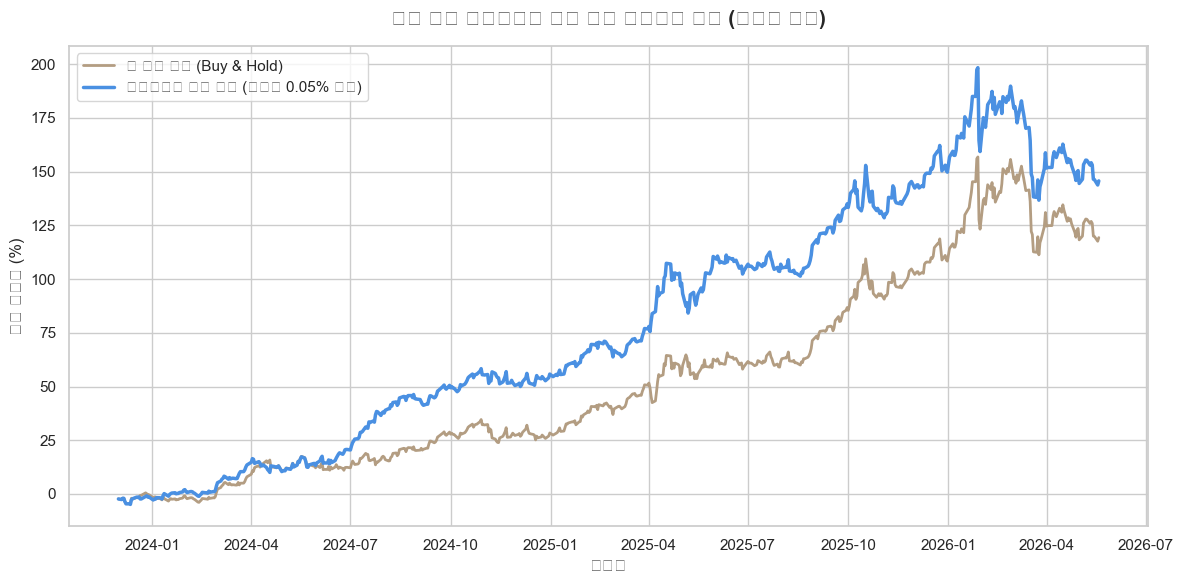

최종 금 단순 보유 누적 수익률: 119.29%
최종 베이스라인 롱숏 누적 수익률: 145.66%
시장 대비 초과수익률 (알파): 26.38%p


In [6]:
# 1. 롱숏 포지션 설정 (상승 1 -> +1 롱 / 하락 0 -> -1 숏)
positions = np.where(y_cls_pred == 1, 1, -1)
fee = 0.0005  # 편도 거래 수수료 0.05%

# 포지션이 변하는 거래일에만 수수료 징수
position_changes = np.diff(positions, prepend=0)
transaction_fees = np.where(position_changes != 0, fee, 0.0)

# 실제 금값 일일 수익률과 결합한 전략 일일 수익률 연산
actual_daily_returns = y_reg_test.values
strategy_daily_returns = actual_daily_returns * positions - transaction_fees

# 누적 복리 수익률 연산
cum_bh = np.cumprod(1 + actual_daily_returns) - 1
cum_strategy = np.cumprod(1 + strategy_daily_returns) - 1

# 판다스 시계열 시각화 프레임 구성
backtest_df = pd.DataFrame({
    'loaded_date': dates_test,
    'Buy & Hold (금 보유)': cum_bh * 100,
    'Baseline Strategy (롱숏 전략)': cum_strategy * 100
}).set_index('loaded_date')

# 2. 고화질 시계열 누적 수익률 시각화
plt.figure(figsize=(12, 6))
plt.plot(backtest_df['Buy & Hold (금 보유)'], label='금 단순 보유 (Buy & Hold)', color='#B39D82', linewidth=2)
plt.plot(backtest_df['Baseline Strategy (롱숏 전략)'], label='베이스라인 롱숏 전략 (수수료 0.05% 차감)', color='#4A90E2', linewidth=2.5)

plt.title('금값 예측 베이스라인 모델 퀀트 백테스팅 비교 (테스트 기간)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('거래일', fontsize=12)
plt.ylabel('누적 수익률 (%)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 최종 백테스트 점수 출력
print(f"최종 금 단순 보유 누적 수익률: {backtest_df['Buy & Hold (금 보유)'].iloc[-1]:.2f}%")
print(f"최종 베이스라인 롱숏 누적 수익률: {backtest_df['Baseline Strategy (롱숏 전략)'].iloc[-1]:.2f}%")
print(f"시장 대비 초과수익률 (알파): {(backtest_df['Baseline Strategy (롱숏 전략)'].iloc[-1] - backtest_df['Buy & Hold (금 보유)'].iloc[-1]):.2f}%p")